# 📊 Notebook 02 — Statistická analýza & EKC
## Kombinovaný styl: Ukázka vzoru → Tvůj úkol

---
- 🔵 **[UKÁZKA]** — kompletní kód, prostuduj a spusť
- 🟡 **[TEĎ TY]** — napiš analogický kód sama

---
## ⚙️ Setup

Tuto buňku spusť vždy jako první — načte data a nastaví prostředí.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os, warnings
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.3f}'.format)

df = pd.read_csv('../output/ekc_analysis.csv')
if 'log_gdp' not in df.columns:
    df['log_gdp'] = np.log(df['mean_gdp'])
income_order = ['Low income', 'Lower middle income', 'Upper middle income', 'High income']
df['income_group'] = pd.Categorical(df['income_group'], categories=income_order, ordered=True)
print(f'Načteno {len(df)} zemí. Sloupce: {df.columns.tolist()}')
assert 180 <= len(df) <= 210, f"Neocekavany pocet zemi: {len(df)} (ocekavano ~199) — zkontroluj notebook 01!"

Načteno 199 zemí. Sloupce: ['country', 'code', 'forest_1990', 'forest_2025', 'forest_change', 'mean_gdp', 'region', 'income_group', 'log_gdp', 'outlier_category']


---
## Sekce 1: Scatter plot HDP vs. lesní pokryv (= Úloha 1)

### 🔵 [UKÁZKA] Scatter plot: `log_gdp` vs. `forest_1990`

Základní nástroj průzkumu dat — vizuálně ukazuje, zda existuje vztah mezi dvěma proměnnými. Každá příjmová skupina dostane jinou barvu.

In [ ]:
# Vzor: Scatter plot se skupinami (income_group) jako barvami
colors = {'Low income': '#d62728', 'Lower middle income': '#ff7f0e',
          'Upper middle income': '#1f77b4', 'High income': '#2ca02c'}

fig, ax = plt.subplots(figsize=(10, 6))
for group in income_order:
    mask = df['income_group'] == group
    ax.scatter(df[mask]['log_gdp'], df[mask]['forest_1990'],
               label=group, color=colors[group], alpha=0.7, s=40)

ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, label='0 % lesa')
ax.set_xlabel('log(HDP per capita)')
ax.set_ylabel('% lesního pokryvu v roce 1990')
ax.set_title('HDP vs. lesní pokryv 1990 — barevně podle příjmové skupiny')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

### 🟡 [TEĎ TY — Grafická kontrola] Scatter plot: `log_gdp` vs. `forest_change` (EKC pohled)

> ℹ️ **Kód je připraven předem** — tvorba vizualizací v Pythonu není cílem tohoto cvičení. Spusť buňku níže a porovnej výsledek s UKÁZKOU výše.

**Co očekávat**: Graf kde vidíš, že chudší země jsou spíše pod y=0 (odlesňování) a bohatší nad y=0 (zalesňování). Tento vizuální vzor je základ EKC hypotézy.

In [ ]:
# Grafická kontrola — kód je připraven předem
# Spusť tuto buňku a porovnej výsledek s UKÁZKOU výše

fig, ax = plt.subplots(figsize=(10, 6))
for group in income_order:
    mask = df['income_group'] == group
    ax.scatter(df[mask]['log_gdp'], df[mask]['forest_change'],
               label=group, color=colors[group], alpha=0.7, s=40)

ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, label='0 — hranice zalesňování')
ax.set_xlabel('log(HDP per capita)')
ax.set_ylabel('Změna lesního pokryvu 1990–2025 [pp]')
ax.set_title('EKC scatter plot: HDP vs. změna lesa (199 zemí)')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

# Kontrolní výpis
above_zero = (df['forest_change'] > 0).sum()
below_zero = (df['forest_change'] < 0).sum()
print(f'Bodů nad y=0 (zalesňování): {above_zero}')
print(f'Bodů pod y=0 (odlesňování): {below_zero}')

---
## Sekce 2: Pearsonova korelace (= Úloha 2)

### 🔵 [UKÁZKA] Korelace: `log_gdp` vs. `forest_1990`

Ukažeme jak vypočítat Pearsonovu korelaci a interpretovat výsledek.


In [2]:
# Vzor: Pearsonova korelace mezi dvěma proměnnými
# stats.pearsonr vrátí (r, p_value)
# r ∈ [-1, 1]: blízko 1 = silná kladná korelace, blízko -1 = silná záporná
# p < 0.05 → výsledek je statisticky významný

data_1 = df[['log_gdp', 'forest_1990']].dropna()
r_demo, p_demo = stats.pearsonr(data_1['log_gdp'], data_1['forest_1990'])

print('Ukázková korelace: log(HDP) vs. % lesa v roce 1990')
print(f'  r = {r_demo:.4f}')
print(f'  p = {p_demo:.4f}')
print(f'  Statisticky významná: {"ANO" if p_demo < 0.05 else "NE"}')
if r_demo > 0:
    print(f'  Interpretace: Bohatší země měly v roce 1990 VÍCE lesa (r > 0)')
else:
    print(f'  Interpretace: Bohatší země měly v roce 1990 MÉNĚ lesa (r < 0)')

Ukázková korelace: log(HDP) vs. % lesa v roce 1990
  r = -0.0624
  p = 0.3814
  Statisticky významná: NE
  Interpretace: Bohatší země měly v roce 1990 MÉNĚ lesa (r < 0)


### 🟡 [TEĎ TY] Korelace: `log_gdp` vs. `forest_change`

**Zadání**: Teď spočítej Pearsonovu korelaci mezi **log(HDP)** a **změnou lesa 1990–2025**.
Toto je klíčová korelace pro Q1 analýzu!

1. Vytvoř DataFrame `cor_data` jen s `log_gdp` a `forest_change` (bez NaN)
2. Spočítej korelaci `stats.pearsonr()`
3. Vypiš r, p-hodnotu a interpretaci
4. **Je korelace statisticky významná?**


**Očekávaný výstup (formát):**
```
Pearsonova korelace: r = 0.3xxx
p-hodnota: 0.00xx
Korelace je statisticky VYZNAMNA (p < 0.05)
```

In [3]:
# TVŮJ KÓD ZDE
# cor_data = df[['log_gdp', 'forest_change']].dropna()
# r, p_value = stats.pearsonr(...)
# ...

> 📝 **Jak číst výsledek:**
> - **Směr** (`r` kladné/záporné): kladné = bohatší země → více lesa; záporné = opak
> - **Síla** (`|r|`): méně než 0.3 = slabá, 0.3–0.7 = střední, nad 0.7 = silná
> - **Průkaznost** (`p < 0.05`): vztah není náhodný, platí statisticky
> - **Zamysli se**: Proč může být korelace slabá, i když EKC platí? (Nápověda: EKC je **nelineární**!)

---
## Sekce 3: Lineární vs. Kvadratická regrese (= Úloha 3)

### 🔵 [UKÁZKA] Lineární regrese: log_gdp → forest_1990


Lineární regrese (forest_1990 vs log_gdp):
  y = -1.047·x + 42.378
  R² = 0.0039 (model vysvětluje 0.4% variance)


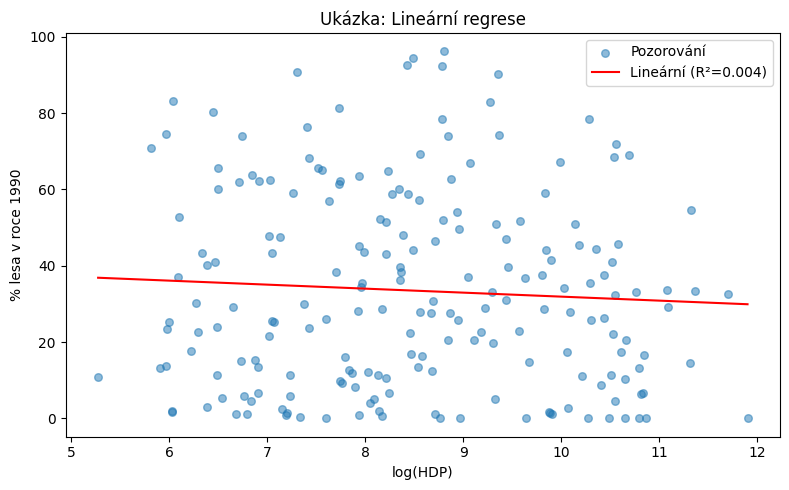

In [4]:
# Vzor: np.polyfit pro polynomiální regresi
# np.polyfit(x, y, deg) → vrátí koeficienty [a, b, ...] od nejvyššího stupně
# deg=1 → lineární (y = a·x + b)
# deg=2 → kvadratická (y = a·x² + b·x + c)

x_demo = data_1['log_gdp'].values
y_demo = data_1['forest_1990'].values

coeffs_lin_demo = np.polyfit(x_demo, y_demo, 1)  # Lineární
print(f'Lineární regrese (forest_1990 vs log_gdp):')
print(f'  y = {coeffs_lin_demo[0]:.3f}·x + {coeffs_lin_demo[1]:.3f}')

# Predikované hodnoty
y_pred_demo = np.polyval(coeffs_lin_demo, x_demo)

# R²
ss_res = np.sum((y_demo - y_pred_demo)**2)
ss_tot = np.sum((y_demo - y_demo.mean())**2)
r2_demo = 1 - ss_res/ss_tot
print(f'  R² = {r2_demo:.4f} (model vysvětluje {r2_demo*100:.1f}% variance)')

# Vizualizace
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x_demo, y_demo, alpha=0.5, s=30, label='Pozorování')
x_line = np.linspace(x_demo.min(), x_demo.max(), 100)
ax.plot(x_line, np.polyval(coeffs_lin_demo, x_line), 'r-', label=f'Lineární (R²={r2_demo:.3f})')
ax.set_xlabel('log(HDP)')
ax.set_ylabel('% lesa v roce 1990')
ax.set_title('Ukázka: Lineární regrese')
ax.legend()
plt.tight_layout()
plt.show()

### 🟡 [TEĎ TY] Kvadratická regrese (EKC): log_gdp → forest_change

**Zadání**: Napiš **kvadratickou** (deg=2) regresi pro klíčová data projektu:
- X = `log_gdp`
- Y = `forest_change`

1. Připrav `x` a `y` (bez NaN)
2. Fit kvadratickým polynomem: `np.polyfit(x, y, 2)` → `coeffs_quad`
3. Výpočet R²
4. Výpočet bodu zlomu (vertex): `x_vertex = -b / (2*a)`, `gdp_inflection = np.exp(x_vertex)`
5. Spusť kontrolní vizualizaci z buňky níže — EKC křivka je připravena předem

> ✅ **Sanity check po výpočtu**:
> - Koeficient `a` by měl být **záporný** → křivka má tvar ∩ (to je EKC). Pokud `a > 0`, křivka je ∪ — zkontroluj, že `x = log_gdp` (ne samotné GDP bez logaritmu).
> - Bod zlomu by měl být přibližně **$5 000–$500 000/os.** Výsledek mimo tento rozsah = chyba ve výpočtu.

<details>
<summary>💡 Proč -b/(2a)?</summary>

Kvadratická funkce `y = ax² + bx + c` má bod zlomu tam, kde derivace `2ax + b = 0`, tedy `x = -b/(2a)`. Přes `np.exp()` převedeš `log(HDP)` zpět na USD — a dostaneš bod zlomu jako HDP na obyvatele.

</details>

**Očekávaný výstup (formát):**
```
Koeficienty: a=-0.36252, b=7.91240, c=-41.49626
Bod zlomu:   $54,885/os.
R²:          0.1456
```

In [ ]:
# TVŮJ KÓD ZDE
# reg_data = df[['log_gdp', 'forest_change']].dropna()
# x = reg_data['log_gdp'].values
# y = reg_data['forest_change'].values

# coeffs_quad = np.polyfit(x, y, 2)
# a, b, c = coeffs_quad

# x_vertex = -b / (2 * a)
# gdp_inflection = np.exp(x_vertex)

# y_pred = np.polyval(coeffs_quad, x)
# ss_res = np.sum((y - y_pred) ** 2)
# ss_tot = np.sum((y - y.mean()) ** 2)
# r_squared = 1 - ss_res / ss_tot

# print(f'Koeficienty: a={a:.5f}, b={b:.5f}, c={c:.5f}')
# print(f'Bod zlomu:   ${gdp_inflection:,.0f}/os.')
# print(f'R²:          {r_squared:.4f}')

In [ ]:
# Grafická kontrola — EKC křivka (kód připraven předem)
# Spusť tuto buňku až po dokončení kroků 1–4 výše
# (musí existovat: coeffs_quad, x_vertex, gdp_inflection)

if 'coeffs_quad' not in dir():
    print('⚠️  Nejdřív dokonči předchozí buňku — coeffs_quad není definováno!')
else:
    reg_data_plot = df[['log_gdp', 'forest_change']].dropna()
    x_plot = reg_data_plot['log_gdp'].values

    fig, ax = plt.subplots(figsize=(10, 6))

    for group in income_order:
        mask = df['income_group'] == group
        ax.scatter(df[mask]['log_gdp'], df[mask]['forest_change'],
                   label=group, color=colors[group], alpha=0.6, s=30)

    x_line = np.linspace(x_plot.min(), x_plot.max(), 200)
    y_line = np.polyval(coeffs_quad, x_line)
    ax.plot(x_line, y_line, 'k-', linewidth=2, label='EKC křivka (deg=2)')

    ax.axvline(x=x_vertex, color='purple', linestyle=':', linewidth=1.5,
               label=f'Bod zlomu: ${gdp_inflection:,.0f}/os.')
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)

    ax.set_xlabel('log(HDP per capita)')
    ax.set_ylabel('Změna lesního pokryvu 1990–2025 [pp]')
    ax.set_title('EKC model: Kvadratická regrese s bodem zlomu')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

> 📝 **Jak číst výsledek:**
> - **Znaménko `a`** (první koeficient): záporné = křivka ve tvaru ∩ (EKC teorie potvrzena)
> - **Bod zlomu v USD**: při jakém HDP se trend obrací? Je to hodnota dostupná pro chudé země?
> - **R²**: kolik procent variance model vysvětluje? Kvadratický model lepší než lineární?
> - **Závěr**: Leží většina zemí pod nebo nad bodem zlomu?

> 📊 **Power BI — vizualizace 1 (Q1 — EKC scatter)**: Bodový graf (Scatter) → osa X: `log_gdp`, osa Y: `forest_change`, barvy: `income_group`. Zdroj: `ekc_analysis.csv`. Viz **PowerBI_pruvodce.md, část 4**.
>
> 📊 **Power BI — vizualizace 2 (Q1 — příjmové skupiny)**: Skupinový sloupcový graf → osa X: `income_group`, osa Y: průměr `forest_change`. Zdroj: `ekc_analysis.csv`. Viz **PowerBI_pruvodce.md, část 4**.

---
## Sekce 4: Test hypotézy — porovnání dvou skupin (= Úloha 4)

### 🔵 [UKÁZKA] Mann-Whitney U test: Low income vs. Lower middle income


In [6]:
# Vzor: Mann-Whitney U test — neparametrický test pro porovnání distribucí
# alternative='greater' → jednostranný test: první skupina > druhá
# alternative='two-sided' → oboustranný test (jakýkoli rozdíl)

low = df[df['income_group'] == 'Low income']['forest_change'].dropna()
lower_mid = df[df['income_group'] == 'Lower middle income']['forest_change'].dropna()

print(f'Low income:           průměr={low.mean():.3f}, n={len(low)}')
print(f'Lower middle income:  průměr={lower_mid.mean():.3f}, n={len(lower_mid)}')

u_stat_demo, p_demo2 = stats.mannwhitneyu(lower_mid, low, alternative='greater')
print(f'\nMann-Whitney U test: Lower middle > Low income')
print(f'  U = {u_stat_demo:.0f}, p = {p_demo2:.4f}')
print(f'  Výsledek: {"Potvrzeno" if p_demo2 < 0.05 else "Nepotvrzeno"}')

Low income:           průměr=-5.547, n=25
Lower middle income:  průměr=-3.911, n=47

Mann-Whitney U test: Lower middle > Low income
  U = 705, p = 0.0831
  Výsledek: Nepotvrzeno


### 🟡 [TEĎ TY] Klíčový test Q1: High income vs. Low income

**Zadání**: Otestuj hlavní hypotézu projektu (Q1):
- H1: **High income** země mají statisticky vyšší změnu lesa než **Low income** země

1. Vyfiltruj `forest_change` pro `High income` a `Low income`
2. Vypiš průměr a počet zemí v obou skupinách — pomůže to při interpretaci výsledku
3. Spusť `stats.mannwhitneyu(high, low, alternative='greater')`
4. Interpretuj výsledek
5. **Bonus**: Spusť jednovýběrový t-test: Je průměrná změna lesa High income > 0?
   → `stats.ttest_1samp(high_income, popmean=0, alternative='greater')`

<details>
<summary>💡 Proč alternative='greater'?</summary>

Říkáme tím, že testujeme **jednostrannou** hypotézu: zajímá nás jen jestli High income je *větší* než Low income. Přesně odpovídá naší H1. Dvoustranný test (`'two-sided'`) by byl konzervativnější a hůře by odhalil tento konkrétní směrový vztah.

</details>

**Očekávaný výstup (formát):**
```
High income: prumer=x.xxx, n=75
Low income:  prumer=-x.xxx, n=25
Mann-Whitney U test: High income > Low income
  U = xxxxx, p = 0.000x
  Vysledek: POTVRZENO
```

In [7]:
# TVŮJ KÓD ZDE


> 📝 **Jak číst výsledek:**
> - **Jednostranný test** (`alternative='greater'`): testujeme konkrétní směr — H1: High > Low
> - **p < 0.05** → H1 potvrzena: High income země skutečně zalesňují více
> - **p >= 0.05** → H0 nezamítnuta: nemáme dostatečný důkaz pro H1
> - **Závěr pro Q1**: Potvrzuje výsledek EKC hypotézu o vlivu bohatství na lesy?

---
## Sekce 5: Porovnání více skupin — Kruskal-Wallis (= Úloha 5)

### 🔵 [UKÁZKA] Kruskal-Wallis test napříč příjmovými skupinami


In [10]:
# Vzor: Kruskal-Wallis — neparametrický test pro VÍCE než 2 skupiny
# Testujeme: Jsou všechny skupiny stejné, nebo se aspoň jedna liší?

income_groups_data = [
    df[df['income_group'] == g]['forest_change'].dropna().values
    for g in income_order
    if g in df['income_group'].values
]

h_stat_demo, p_kw_demo = stats.kruskal(*income_groups_data)

print(f'Kruskal-Wallis test: Jsou rozdíly mezi příjmovými skupinami statisticky významné?')
print(f'  H = {h_stat_demo:.4f}')
print(f'  p = {p_kw_demo:.6f}')
print(f'  Výsledek: {"STATISTICKY VÝZNAMNÉ" if p_kw_demo < 0.05 else "NEVÝZNAMNÉ"}')

Kruskal-Wallis test: Jsou rozdíly mezi příjmovými skupinami statisticky významné?
  H = 36.6479
  p = 0.000000
  Výsledek: STATISTICKY VÝZNAMNÉ


### 🟡 [TEĎ TY] Kruskal-Wallis test přes regiony

**Zadání**: Spusť stejný test pro **regiony** (místo příjmových skupin).
Tím odpovíš na výzkumnou otázku Q2: Jsou regionální rozdíly statisticky průkazné?

1. Vytvoř list polí `forest_change` pro každý region
2. Odstraň prázdné skupiny: `region_groups = [g for g in region_groups if len(g) > 0]`
3. Spusť `stats.kruskal(*region_groups)`
4. Interpretuj výsledek


**Očekávaný výstup (formát):**
```
Kruskal-Wallis test: Jsou regionalni rozdily statisticky prkazne?
  H = xx.xxxx
  p = 0.000xxx
  Vysledek: ANO - regionalni rozdily jsou statisticky VYZNAMNE
```

In [11]:
# TVŮJ KÓD ZDE
# region_groups = [
#     df[df['region'] == r]['forest_change'].dropna().values
#     for r in df['region'].dropna().unique()
# ]
# region_groups = [g for g in region_groups if len(g) > 0]
# h_stat, p_kw = stats.kruskal(*region_groups)
# ...

> 📝 **Jak číst výsledek:**
> - Kruskal-Wallis testuje, zda **aspoň jeden** region se liší od ostatních
> - Statisticky významný výsledek = rozdíly jsou příliš velké na to, aby byly náhodné
> - Test **neřekne** které regiony se liší — to by vyžadovalo post-hoc analýzu
> - **Závěr pro Q2**: Závisí změna lesa na geografické poloze nad rámec ekonomiky?

> 📊 **Power BI — vizualizace 3 (Q2 — regiony)**: Sloupcový graf (vodorovný) → osa Y: `region`, osa X: `mean_change`, barvy: `region`. Zdroj: `regional_summary.csv`. Viz **PowerBI_pruvodce.md, část 4**.

---
## Sekce 6: Kvartily a outliers — Paradoxní země (= Úloha 6)

### 🔵 [UKÁZKA] Kvartilová analýza: forest_change

In [ ]:
# Vzor: Výpočet kvartilů a identifikace outlierů metodou IQR
# Kvartily rozdělí data na 4 stejné části
# Q1 = 25% hodnot je pod touto hranicí
# Q3 = 75% hodnot je pod touto hranicí
# IQR = Q3 - Q1 (mezikvartiové rozpětí)

q1 = df['forest_change'].quantile(0.25)
q2 = df['forest_change'].quantile(0.50)  # Medián
q3 = df['forest_change'].quantile(0.75)
iqr = q3 - q1

lower_fence = q1 - 1.5 * iqr  # Dolní hranice outlierů
upper_fence = q3 + 1.5 * iqr  # Horní hranice outlierů

outliers_iqr = df[(df['forest_change'] < lower_fence) | (df['forest_change'] > upper_fence)]

print(f'Kvartily forest_change:')
print(f'  Q1 (25%):  {q1:.3f}%')
print(f'  Q2 (50%):  {q2:.3f}%  (medián)')
print(f'  Q3 (75%):  {q3:.3f}%')
print(f'  IQR:       {iqr:.3f}')
print(f'  Outliery (IQR metoda): {len(outliers_iqr)} zemí')

### 🟡 [TEĎ TY] Paradoxní země (Q3 analýza)

> ⚠️ **Pozor**: Ukázka výše hledala outliery v `forest_change` (IQR metoda).
> Tady děláme **jinou analýzu**: kvartily `mean_gdp` (bohatství), abychom
> identifikovali ekonomicky **paradoxní** země — bohaté co odlesňují a chudé co zalesňují.

**Zadání**: Identifikuj "paradoxní" země podle EKC teorie:

1. Vypočítej Q75 a Q25 pro **`mean_gdp`** (ne forest_change)
2. Filtruj **bohaté odlesňovatelé**: `mean_gdp > Q75 GDP` AND `forest_change < 0`
3. Filtruj **chudé zalesňovatelé**: `mean_gdp < Q25 GDP` AND `forest_change > 0.5`
4. Vypiš obě skupiny
5. Přidej do `df` sloupec `outlier_category` ('rich_deforester', 'poor_reforester', 'expected_positive', 'expected_negative')

<details>
<summary>💡 Proč forest_change > 0.5 a ne > 0?</summary>

Malé kladné hodnoty (0–0.5 %) mohou být měřicí šum nebo zaokrouhlení. Práh 0.5 % vyžaduje reálné, viditelné zalesňování — ne jen statistický artefakt.

</details>

<details>
<summary>💡 Nápověda: funkce classify — logika klasifikace</summary>

Přidej kategorie pomocí `df.apply(classify, axis=1)`, kde `classify(row)` je pomocná funkce. Logika pro všechna 4 pásma:

- `'rich_deforester'` → row['mean_gdp'] > q75_gdp AND row['forest_change'] < 0
- `'poor_reforester'` → row['mean_gdp'] < q25_gdp AND row['forest_change'] > 0.5
- `'expected_positive'` → vše ostatní s forest_change ≥ 0 (zalesňování — odpovídá EKC)
- `'expected_negative'` → vše ostatní s forest_change < 0 (odlesňování — odpovídá EKC)

</details>

**Očekávaný výstup (formát):**
```
Bohaté odlesňovatelé (8):
  Brunei, South Korea, Cayman Islands, Sweden, Norway, Belgium, Australia, Japan

Chudé zalesňovatelé (6):
  Rwanda, Ghana, Nepal, Uzbekistan, India, Kyrgyzstan
```

In [ ]:
# TVŮJ KÓD ZDE

> 📊 **Power BI — vizualizace 4 (Q3 — mapa světa)**: Choropleth mapa → umístění: `code`, barva: `forest_change`. Zdroj: `ekc_analysis.csv`. Viz **PowerBI_pruvodce.md, část 4**.
>
> 📊 **Power BI — vizualizace 5 (Q3 — paradoxní země)**: Tabulka → sloupce: `country`, `income_group`, `forest_change`, `outlier_category`, `policy_score`. Zdroj: `outliers_with_policy.csv`. Viz **PowerBI_pruvodce.md, část 4**.

---
## Sekce 7: Forest Policy (= Úloha 7)

### 🔵 [UKÁZKA] Načtení a zpracování policy dat

In [ ]:
# Vzor: Načtení FAO Forest Policy dat a vytvoření policy score
fp_raw = pd.read_csv('../../data_raw/Forest_Policy_Legislation.csv', on_bad_lines='skip')
fp = fp_raw[['iso3', 'National policies supporting SFM',
             'National legislations supporting SFM',
             'National platform for stakeholder participation']].copy()
fp.columns = ['code', 'has_policy', 'has_legislation', 'has_platform']

# Konverze yes/no → True/False
for col in ['has_policy', 'has_legislation', 'has_platform']:
    fp[col] = fp[col].str.strip().str.lower().map({'yes': True, 'no': False})

# Policy score = počet zavedených opatření
fp['policy_score'] = fp[['has_policy', 'has_legislation', 'has_platform']].sum(axis=1)

print(f'Forest Policy data načtena: {len(fp)} zemí')
print(f'Policy score distribuce:')
print(fp['policy_score'].value_counts().sort_index())
print(f'\nPříklad:')
print(fp[fp['code'].isin(['CZE', 'ETH', 'BRA', 'DEU'])][['code', 'has_policy', 'has_legislation', 'policy_score']])

### 🟡 [TEĎ TY] Analýza: Mají paradoxní země jinou politiku?

**Zadání**: Propoj policy data s paradoxními zeměmi ze Sekce 6 (outlier_category):
1. `pd.merge(df[df['outlier_category'].isin(['rich_deforester', 'poor_reforester'])], fp, on='code', how='left')`
2. Porovnej průměrný `policy_score` pro `rich_deforester` vs. `poor_reforester`
3. Nakresli scatter plot: `policy_score` (x) vs. `forest_change` (y), barva podle kategorie
4. **Závěr**: Hraje lesní politika roli u paradoxních zemí?

**Očekávaný výstup (formát):**
```
                  n   mean  median
outlier_category
poor_reforester   6  2.833   3.000
rich_deforester   8  2.750   3.000
```

> 🔍 **Co to znamená**: Obě skupiny mají téměř shodný a vysoký policy score (~2.75–2.83 z max 3). Lesní politika sama o sobě neodlišuje paradoxní země — jiné faktory hrají větší roli.

In [13]:
# TVŮJ KÓD ZDE


---
## Sekce 8: Export výstupů pro Power BI (= Úloha 8)

### 🔵 [UKÁZKA] Export regionálního souhrnu


In [14]:
# Vzor: Export DataFrame do CSV
os.makedirs('../output', exist_ok=True)

regional_summary = (
    df.groupby('region')['forest_change']
    .agg(n='count', mean_change='mean', median_change='median', std_change='std')
    .sort_values('mean_change')
    .round(3)
    .reset_index()
)
regional_summary.to_csv('../output/regional_summary.csv', index=False, encoding='utf-8-sig')
print(f'✅ Uloženo regional_summary.csv ({len(regional_summary)} regionů)')

✅ Uloženo regional_summary.csv (7 regionů)


### 🟡 [TEĎ TY] Export ostatních souborů pro Power BI

**Zadání**: Exportuj zbývající soubory do `../output/`:
1. `ekc_analysis.csv` — hlavní dataset `df` (s outlier_category)
2. `ekc_regression_curve.csv` — 100 bodů pro EKC křivku
   - `x_line = np.linspace(df['log_gdp'].min(), df['log_gdp'].max(), 100)`
   - DataFrame se sloupci: `log_gdp_fit`, `gdp_fit`, `forest_pred`
   - Použij `coeffs_quad` z Sekce 3
3. `outliers.csv` — paradoxní země (kde `outlier_category` je 'rich_deforester' nebo 'poor_reforester')
4. `outliers_with_policy.csv` — paradoxní země + policy data (ze Sekce 7)
   - Použij `outlier_policy` ze Sekce 7, vyber sloupce:
     `country`, `income_group`, `region`, `mean_gdp`, `forest_change`,
     `outlier_category`, `has_policy`, `has_legislation`, `policy_score`

> ℹ️ Export vyžaduje proměnné z předchozích sekcí: `coeffs_quad` (Sekce 3), `outlier_policy` (Sekce 7) — spusť je nejdřív.

**Očekávaný výstup:**
```
✅ ekc_analysis.csv          (199 řádků)
✅ ekc_regression_curve.csv  (100 bodů pro EKC křivku)
✅ outliers.csv              (14 zemí — 8 rich_deforester + 6 poor_reforester)
✅ outliers_with_policy.csv
```

> ✅ **Ověření**: Otevři složku `../output/` v Průzkumníku souborů — všechny soubory musí existovat. Zkontroluj `ekc_regression_curve.csv` v Excelu — měla by mít přesně 100 řádků a sloupce `log_gdp_fit`, `gdp_fit`, `forest_pred`.

In [15]:
# TVŮJ KÓD ZDE


---
## ✅ Hotovo?

Zkontroluj:
- [ ] Scatter plot HDP vs. změna lesa nakreslen (Sekce 1)
- [ ] Korelace spočítána a interpretována (Sekce 2)
- [ ] EKC křivka nakreslena, bod zlomu vypočítán (Sekce 3)
- [ ] Mann-Whitney test pro Q1 proveden (Sekce 4)
- [ ] Kruskal-Wallis test pro Q2 proveden (Sekce 5)
- [ ] Paradoxní země identifikovány, sloupec `outlier_category` přidán (Sekce 6)
- [ ] Forest Policy analýza provedena (Sekce 7)
- [ ] 5 souborů exportováno do `../output/` (Sekce 8)

**Pokračuj**: [`../PowerBI_pruvodce.md`](../PowerBI_pruvodce.md)
**Bonus**: `03_sql_bonus.ipynb`